# Identification in structural VARs: Cholesky vs sign restrictions

## A case study using U.S. monetary policy data

In October 1979, Paul Volcker's Federal Reserve raised the federal funds rate from 11% to over 17% in a matter of weeks. Industrial production fell. Unemployment rose. Inflation, eventually, came down. Most macroeconomists agree on this basic narrative: the Fed tightened, and the economy contracted.

But suppose you did not know the history and only had the data. You would see that output, prices, and interest rates move together over time. You would not know *why*. Did the Fed raise rates, causing output to fall? Or did output fall for other reasons, prompting the Fed to respond? The raw correlations are consistent with both stories, and with many others.

A vector autoregression (VAR) captures these co-movements in a system of linear equations, where each variable depends on its own past and the past of the other variables. The residuals from this system tell you what is left after accounting for predictable dynamics. But those residuals are correlated across equations. Disentangling them into economically meaningful shocks -- a monetary policy shock, a supply shock, a demand shock -- requires additional assumptions beyond what the data can provide. This is the identification problem, and how you solve it determines what you conclude.

This notebook works through two identification strategies on the same dataset:

1. Cholesky decomposition imposes a recursive causal ordering among the variables. The ordering determines which variables can respond to which shocks within the period. It delivers a unique, point-identified structural decomposition. Change the ordering and you change the answer.

2. Sign restrictions impose qualitative constraints on the *direction* of responses (e.g., "a contractionary monetary shock does not increase prices"). Instead of a single decomposition, you get a *set* of admissible decompositions. The credible bands are wider, but they reflect genuine uncertainty about identification that Cholesky hides.

By running both on the same data, we can see concretely how assumptions drive conclusions: how the ordering matters, why the price puzzle appears and what it signals, and why wider bands under sign restrictions are not a failure but an honest accounting of what the data alone can tell us.

In [ ]:
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("pytensor").setLevel(logging.ERROR)

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from impulso import VAR, VARData, select_lag_order
from impulso.identification import Cholesky, SignRestriction
from impulso.samplers import NUTSSampler

## Data

We use the three-variable system that has been the workhorse of the monetary policy SVAR literature since Sims (1980):

| Variable | FRED code | What it measures | Transformation |
|----------|-----------|-----------------|----------------|
| output | `INDPRO` | Industrial production index | $100 \times \log$ |
| prices | `CPIAUCSL` | Consumer price index (all urban) | $100 \times \log$ |
| rate | `FEDFUNDS` | Effective federal funds rate | Level (%) |

Why these three? Industrial production is a monthly measure of real economic activity (GDP is only quarterly). The CPI captures the price level. The federal funds rate is the Fed's primary policy instrument over this sample period. Together, they form the minimal system needed to study how monetary policy affects the real economy and prices.

The sample runs from January 1965 to December 2007. The start date captures the post-Accord era when the Fed actively targeted the funds rate. The end date is deliberate: from December 2008 onward, the funds rate sat at the zero lower bound, and conventional identification of monetary policy shocks breaks down. You cannot identify a "surprise tightening" when the rate is pinned at zero.

Industrial production and CPI enter the VAR as $100 \times \log(\cdot)$, so a one-unit change is approximately a one-percent change. The federal funds rate enters in levels (percentage points). We do not difference the data. Sims, Stock, and Watson (1990) showed that Bayesian inference in levels VARs is valid regardless of whether the series have unit roots, and differencing can distort impulse responses when variables are cointegrated.

In [ ]:
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

DATA_CACHE = Path("data/monetary_policy.csv")

if DATA_CACHE.exists():
    df = pd.read_csv(DATA_CACHE, index_col="date", parse_dates=True)
    print(f"Loaded cached data: {len(df)} observations")
else:
    from fredapi import Fred

    fred = Fred()  # Reads FRED_API_KEY from environment

    indpro = fred.get_series("INDPRO", observation_start="1965-01-01", observation_end="2007-12-31")
    cpi = fred.get_series("CPIAUCSL", observation_start="1965-01-01", observation_end="2007-12-31")
    fedfunds = fred.get_series("FEDFUNDS", observation_start="1965-01-01", observation_end="2007-12-31")

    df = pd.DataFrame({
        "output": np.log(indpro) * 100,
        "prices": np.log(cpi) * 100,
        "rate": fedfunds,
    }).dropna()
    df.index.name = "date"

    DATA_CACHE.parent.mkdir(exist_ok=True)
    df.to_csv(DATA_CACHE)
    print(f"Downloaded and cached {len(df)} observations")

df.describe().round(2)

Loaded cached data: 516 observations


,output,prices,rate
count,516.00,516.00,516.00
mean,406.30,454.34,6.44
std,33.31,60.45,3.27
min,341.18,344.30,0.98
25%,381.15,400.41,4.60
50%,401.33,469.73,5.56
75%,437.08,507.41,8.23
max,462.87,535.40,19.10


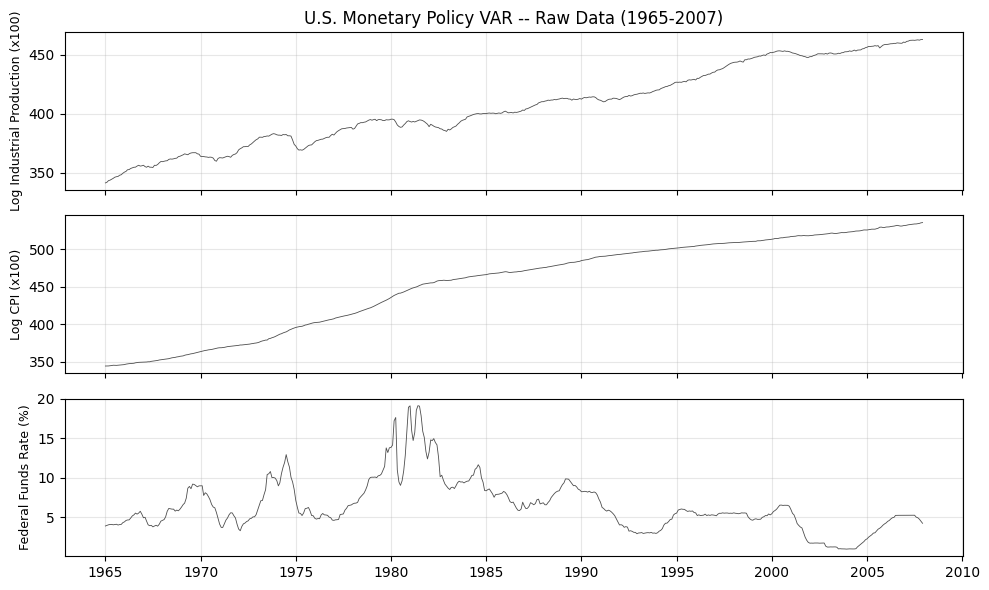

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
labels = {
    "output": "Log Industrial Production (x100)",
    "prices": "Log CPI (x100)",
    "rate": "Federal Funds Rate (%)",
}

for ax, col in zip(axes, df.columns, strict=True):
    ax.plot(df.index, df[col], linewidth=0.6, color="0.3")
    ax.set_ylabel(labels[col], fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_title("U.S. Monetary Policy VAR -- Raw Data (1965-2007)")
fig.tight_layout()

## Reduced-form VAR estimation

The reduced-form VAR($p$) model is:

$$y_t = c + A_1 y_{t-1} + A_2 y_{t-2} + \cdots + A_p y_{t-p} + u_t, \qquad u_t \sim N(0, \Sigma_u)$$

where $y_t = (\text{output}_t, \text{prices}_t, \text{rate}_t)'$ is the $3 \times 1$ vector of endogenous variables, $c$ is a vector of intercepts, and $A_1, \ldots, A_p$ are $3 \times 3$ coefficient matrices. Each $A_j$ captures how the variables at lag $j$ feed back into the current period.

The term $u_t$ is the reduced-form residual. It is what is left over after the systematic linear dependence on past values has been accounted for. These residuals are correlated across equations: $\Sigma_u$ is not diagonal. The off-diagonal elements of $\Sigma_u$ tell us, for instance, that when the output residual is large and positive, the interest rate residual tends to be large too. But they do not tell us which caused which. That ambiguity is the identification problem, which we return to below.

We estimate this model with a Minnesota (Litterman) prior. The idea behind Minnesota is simple: most macroeconomic time series look roughly like random walks, so a good starting point is to shrink each variable's own first lag toward 1 and everything else toward 0. Cross-variable lags get shrunk harder than own lags, and higher lags get shrunk harder than lower ones. This regularisation is important for monthly VARs with many lags, where the number of free parameters (here $3 \times 3 \times 12 = 108$ in the $A$ matrices alone, plus 3 intercepts) can overwhelm the data.

In [ ]:
data = VARData.from_df(df, endog=["output", "prices", "rate"])

ic = select_lag_order(data, max_lags=14)
print(f"AIC: {ic.aic} lags, BIC: {ic.bic} lags, HQ: {ic.hq} lags")
ic.summary()

AIC: 14 lags, BIC: 2 lags, HQ: 3 lags


,aic,bic,hq
lag,,,
1,-4.703247,-4.604354,-4.664491
2,-5.118009,-4.944689,-5.050079
3,-5.189943,-4.941973,-5.092747
4,-5.188799,-4.865958,-5.062245
5,-5.190772,-4.792835,-5.034768
6,-5.187551,-4.714293,-5.002003
7,-5.184203,-4.635399,-4.969018
8,-5.210401,-4.585822,-4.965483
9,-5.213056,-4.512474,-4.938312


The standard choice for monthly monetary policy VARs is 12 lags, which allows the model to capture up to one year of dynamic feedback. We follow this convention for comparability with published results (Christiano, Eichenbaum, and Evans, 1999; Uhlig, 2005). The information criteria above suggest shorter lag lengths, but information criteria are designed for forecasting, not structural analysis, and shorter lags can truncate dynamics that matter for impulse responses at longer horizons.

In [ ]:
sampler = NUTSSampler(
    draws=1500,
    tune=3000,
    chains=8,
    cores=8,
    random_seed=123,
    target_accept=0.9,
    nuts_sampler="nutpie",
)
fitted = VAR(lags=12, prior="minnesota").fit(data, sampler=sampler)
fitted

Progress,Draws,Divergences,Step Size,Gradients/Draw
,4500,0,0.01,1023
,4500,0,0.01,1023
,4500,0,0.01,1023
,4500,0,0.01,1023
,4500,0,0.01,1023
,4500,0,0.01,1023
,4500,0,0.01,1023
,4500,0,0.01,1023


FittedVAR(n_lags=12, data=VARData(endog_names=['output', 'prices', 'rate'], exog_names=None), var_names=['output', 'prices', 'rate'], has_exog=False)

In [ ]:
summary = az.summary(fitted.idata, var_names=["intercept"], kind="diagnostics")
print(f"Max R-hat: {summary['r_hat'].max():.3f}")
print(f"Min ESS (bulk): {summary['ess_bulk'].min():.0f}")
print(f"Divergences: {fitted.idata.sample_stats['diverging'].sum().values}")

Max R-hat: 1.010
Min ESS (bulk): 2981
Divergences: 0


The sampler has converged well: no divergences, R-hat close to 1, and effective sample sizes comfortably above 1,000.

A note on prior sensitivity: we use the default Minnesota prior hyperparameters from impulso throughout this notebook. The overall tightness, cross-variable shrinkage, and lag decay parameters all affect the posterior and hence the impulse responses. A full prior sensitivity analysis — varying $\lambda_1$ across a range like 0.05 to 0.5 — would be a valuable robustness exercise, but we defer it here to keep the focus on identification. The reader should be aware that the choice of prior is an additional modelling decision on top of the identification strategy, and in principle both should be subjected to sensitivity analysis in applied work.

## The identification problem

We now have posterior draws of the reduced-form parameters: the coefficient matrices $A_1, \ldots, A_p$ and the residual covariance $\Sigma_u$. The reduced-form residuals $u_t$ are correlated across equations, but we want to recover the *structural* shocks $\varepsilon_t$, which are orthogonal (uncorrelated with each other) and have an economic interpretation: an output shock, a price shock, a monetary policy shock.

The structural model assumes:

$$u_t = B_0 \, \varepsilon_t, \qquad \varepsilon_t \sim N(0, I_n)$$

where $B_0$ is the $n \times n$ structural impact matrix. Column $j$ of $B_0$ describes how a one-standard-deviation structural shock $j$ moves each variable on impact. The orthogonality assumption $\text{Var}(\varepsilon_t) = I_n$ means the structural shocks are uncorrelated and unit-variance, so all the interesting structure lives in $B_0$.

Since $\Sigma_u = \text{Var}(u_t) = B_0 \, B_0'$, we can in principle recover $B_0$ from $\Sigma_u$. But here is the problem. For $n = 3$ variables, the symmetric matrix $\Sigma_u$ has $n(n+1)/2 = 6$ unique elements. The matrix $B_0$ has $n^2 = 9$ free entries. Six equations, nine unknowns. We are three restrictions short.

Without additional restrictions, there are infinitely many matrices $B_0$ that satisfy $\Sigma_u = B_0 B_0'$. If $B_0$ is one solution, then $B_0 Q$ is another for any orthogonal matrix $Q$ (since $B_0 Q (B_0 Q)' = B_0 Q Q' B_0' = B_0 B_0' = \Sigma_u$). The data cannot tell these apart. The choice of $Q$ is the identification problem.

It is worth pausing on why this works. An orthogonal matrix $Q$ satisfies $Q Q' = I_n$: it is a rotation (or reflection) that preserves lengths and angles. When we form $B_0 Q$, we are rotating the columns of $B_0$ — redistributing the structural shocks into new linear combinations — without changing the covariance they imply. Every such rotation gives a different economic story (different shocks, different impulse responses) that is equally consistent with the observed data. The identification problem is not a generic "too many unknowns" issue; it is specifically a *rotational* indeterminacy, and the two strategies below differ in how they resolve it: Cholesky pins the rotation to the identity by choosing the unique lower-triangular factor, while sign restrictions accept all rotations that satisfy qualitative constraints.

Two ways to resolve it:

**Cholesky decomposition.** Force $B_0$ to be lower triangular, which pins down $Q$ uniquely. This imposes $n(n-1)/2 = 3$ zeros above the diagonal. These zeros have direct economic meaning: they say that certain variables cannot respond to certain shocks within the period.

**Sign restrictions.** Instead of zeros, impose inequality constraints on the elements of $B_0$ (or on the impulse responses it implies). Accept all rotation matrices $Q$ that produce a $B_0 Q$ consistent with these constraints. This gives a *set* of admissible models rather than a single point.

## Cholesky identification

The Cholesky decomposition factors $\Sigma_u$ into $L L'$ where $L$ is lower triangular with positive diagonal entries. Setting $B_0 = L$ gives us a structural impact matrix where the zeros above the diagonal carry specific economic meaning determined by the variable ordering.

Our baseline ordering is: output, prices, rate. Written out, $B_0$ looks like:

$$B_0 = \begin{pmatrix} * & 0 & 0 \\ * & * & 0 \\ * & * & * \end{pmatrix}$$

Read column by column. The first column is the "output shock": it can move all three variables on impact. The second column is the "price shock": it can move prices and the rate, but not output (the zero in position $(1,2)$). The third column is the "rate shock" (our monetary policy shock): it can only move the rate on impact, not output or prices (the zeros in positions $(1,3)$ and $(2,3)$).

What does this mean economically? The zeros say that output and prices are "sluggish" within the month and cannot respond contemporaneously to a monetary policy shock. The Fed, by contrast, sits in the last row and can see and respond to everything. This is a timing assumption: it takes at least one month for a change in the funds rate to show up in industrial production or consumer prices, but the FOMC can observe current economic conditions and adjust policy within the month.

The monetary policy shock itself is the residual variation in the funds rate equation after removing the systematic response to current output and prices. If the Fed raises rates by more than its usual reaction to the current state of the economy, the excess is the "shock."

This is a defensible set of assumptions for monthly data, but it is not the only defensible set. The three zeros are doing real work, and different zeros give different answers.

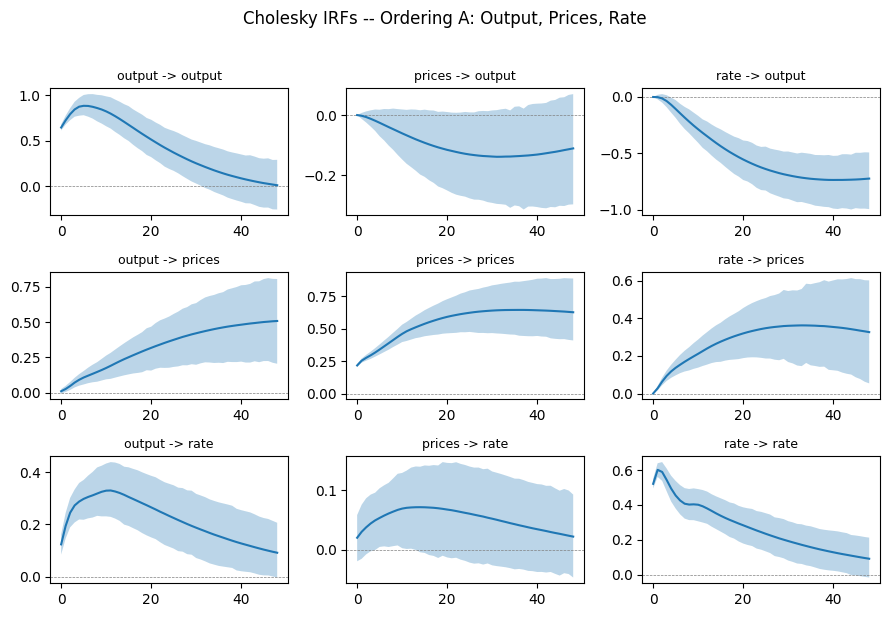

In [ ]:
ordering_a = ["output", "prices", "rate"]
identified_chol_a = fitted.set_identification_strategy(Cholesky(ordering=ordering_a))

irf_chol_a = identified_chol_a.impulse_response(horizon=48)
fig = irf_chol_a.plot()
fig.suptitle("Cholesky IRFs -- Ordering A: Output, Prices, Rate", y=1.02)
plt.savefig("plots/CholeskyIRFs.png")

The 3x3 grid above shows every shock-response pair. Read it as "column shock causes row response." Focus on the third column (the rate shock, i.e. the identified monetary policy shock):

- **rate -> output** (top right): Industrial production drops sharply after a contractionary monetary shock, falling by about 0.5 to 1.0 units over 48 months. This is the standard transmission mechanism: higher rates reduce investment and consumption, which reduces output. The response is persistent, with no clear sign of returning to zero within 4 years.

- **rate -> rate** (bottom right): The rate shock itself starts at about 0.6 and decays gradually. The policy tightening is partially reversed over time, consistent with the Fed easing as the economy weakens.

- **rate -> prices** (middle right): Here is the problem. After a contractionary monetary shock, prices *rise*. The CPI response is positive, reaching about 0.3-0.4 over 48 months. This is the **price puzzle**: tighter monetary policy is supposed to reduce inflation, yet the estimated response goes the wrong way.

Why does this happen? The most common explanation: the Fed raises rates when it expects future inflation. A three-variable VAR cannot capture the Fed's information set, so the "surprise" component of the rate change still contains a systematic response to anticipated inflation. The subsequent price increase is not caused by the rate hike; it is the inflation the Fed saw coming. The "shock" is not really a shock.

Sims (1992) and Christiano, Eichenbaum, and Evans (1999) argued that adding commodity prices to the VAR can help resolve this, because commodity prices capture forward-looking inflation signals the Fed responds to. We stick with three variables here to illustrate the problem clearly.

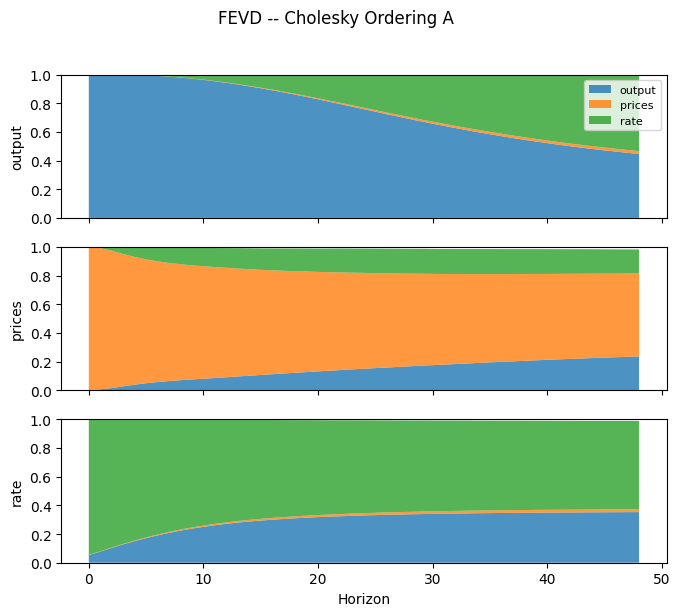

In [ ]:
fevd_chol_a = identified_chol_a.fevd(horizon=48)
fig = fevd_chol_a.plot()
fig.suptitle("FEVD -- Cholesky Ordering A", y=1.02)
plt.savefig("plots/FEVD_Cholesky.png")

The forecast error variance decomposition shows how much of each variable's unpredictable variation is attributable to each structural shock at different horizons.

Focus on the monetary policy shock (the rate shock, third column). In the literature, monetary policy shocks typically account for 10–20% of the forecast error variance in output at business-cycle horizons (12–24 months). This is a useful benchmark: monetary policy matters, but it is not the dominant driver of output fluctuations. Most of the variation in industrial production is explained by its own shocks (supply and demand disturbances that are not monetary in origin).

For prices, the monetary policy shock explains relatively little of the forecast error variance, which is consistent with the price puzzle: the identified shock is pushing prices in the wrong direction, so it cannot be a major explanatory factor for price movements. The rate itself is largely explained by its own shock at short horizons, but the contribution of output and price shocks grows at longer horizons as the Fed's systematic reaction function feeds back.

### Sensitivity to variable ordering

If the Cholesky ordering embodies economic assumptions, then changing the ordering changes the assumptions and should change the results. Let us see by how much.

We compare three orderings, each implying a different contemporaneous causal structure:

- **Ordering A (baseline):** output, prices, rate. Output and prices are sluggish; the Fed sees everything.
- **Ordering B:** prices, output, rate. Prices ordered before output, so prices can affect output contemporaneously but not vice versa. The Fed still sees everything.
- **Ordering C:** rate, output, prices. The interest rate is ordered *first*, meaning it is assumed to be the most exogenous variable, unable to respond to current output or prices within the month. This is economically backwards for a central bank that watches real-time data, but it is instructive to see what happens when the ordering is wrong.

In [ ]:
# Ordering B: prices, output, rate
ordering_b = ["prices", "output", "rate"]
identified_chol_b = fitted.set_identification_strategy(Cholesky(ordering=ordering_b))
irf_chol_b = identified_chol_b.impulse_response(horizon=48)

# Ordering C: rate, output, prices (rate most exogenous)
ordering_c = ["rate", "output", "prices"]
identified_chol_c = fitted.set_identification_strategy(Cholesky(ordering=ordering_c))
irf_chol_c = identified_chol_c.impulse_response(horizon=48)

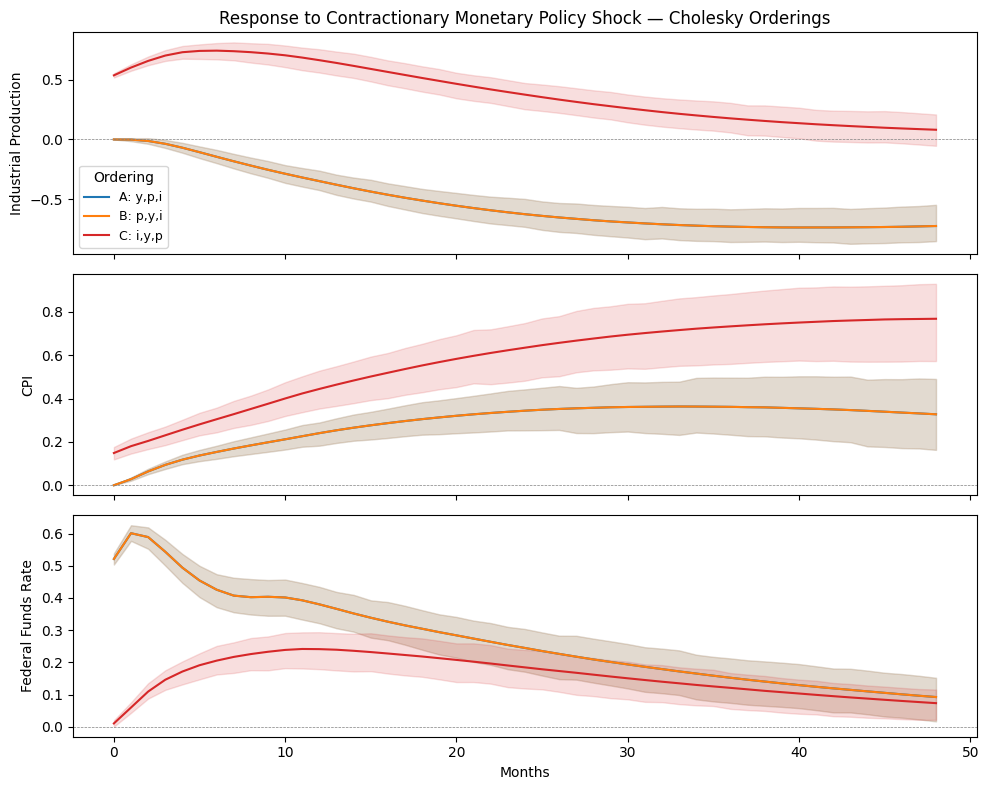

In [ ]:
response_vars = ["output", "prices", "rate"]
response_labels = {
    "output": "Industrial Production",
    "prices": "CPI",
    "rate": "Federal Funds Rate",
}
horizons = np.arange(49)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i, resp in enumerate(response_vars):
    ax = axes[i]

    for label, irf_result, colour in [
        ("A: y,p,i", irf_chol_a, "C0"),
        ("B: p,y,i", irf_chol_b, "C1"),
        ("C: i,y,p", irf_chol_c, "C3"),
    ]:
        irf_data = irf_result.idata.posterior_predictive["irf"]
        med_vals = irf_data.sel(response=resp, shock="rate").median(dim=("chain", "draw")).values
        hdi_ds = az.hdi(irf_data.sel(response=resp, shock="rate"), hdi_prob=0.68)
        hdi_vals = hdi_ds["irf"]

        ax.plot(horizons, med_vals, color=colour, label=label, linewidth=1.5)
        ax.fill_between(
            horizons,
            hdi_vals.sel(hdi="lower").values,
            hdi_vals.sel(hdi="higher").values,
            alpha=0.15,
            color=colour,
        )

    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_ylabel(response_labels[resp])
    if i == 0:
        ax.legend(fontsize=9, title="Ordering")
        ax.set_title("Response to Contractionary Monetary Policy Shock — Cholesky Orderings")

axes[-1].set_xlabel("Months")
fig.tight_layout()
plt.savefig("plots/Cholesky_Orderings.png")

The three orderings produce noticeably different impulse responses to a monetary policy shock.

**Output (top panel).** Orderings A and B produce *identical* impulse responses — not merely similar, but exactly the same. This is not a coincidence. In both orderings, the federal funds rate sits in position 3 (last), so the monetary policy shock is the third column of the lower-triangular $B_0$, which depends only on the Cholesky factor's third column. Swapping output and prices in positions 1 and 2 changes the output shock and the price shock, but leaves the monetary policy shock untouched. This is a useful structural insight: ordering sensitivity for a given shock depends on *where that shock's variable sits in the ordering*, not on the full permutation. The monetary policy shock only changes when the rate moves to a different position, as in ordering C.

Ordering C tells a starkly different story: output *rises* initially, staying positive for the first 20 months before declining only slightly. When the rate is ordered first, the "monetary policy shock" no longer cleanly separates unexpected policy from the Fed's systematic response, so the estimated effect is contaminated.

**Prices (middle panel).** The price puzzle appears in all three orderings, but to very different degrees. Orderings A and B show moderate price increases (around 0.2-0.4) — again identical, for the same reason. Ordering C produces the most severe puzzle, with prices rising by 0.6-0.8. With the rate most exogenous, less of the Fed's systematic response to inflation is stripped out, so the "shock" still contains the Fed's reaction to anticipated inflation.

**Rate (bottom panel).** Orderings A and B produce a large initial rate increase (~0.6 percentage points) that decays over 4 years. Ordering C shows a much smaller initial impact (~0.2) because, with the rate first, the shock is measured differently.

The lesson is clear. The monetary policy shock is invariant to the ordering of variables that come *before* it (orderings A and B), but changes fundamentally when the rate itself moves to a different position (ordering C). Ordering C, which makes an economically implausible assumption about the Fed, gives a qualitatively different answer. These differences are not coming from the data. They come entirely from the three zeros we chose to impose.

## Sign restrictions

Sign restrictions take a different approach to the identification problem. Instead of asserting that specific elements of $B_0$ are exactly zero, we assert only the *direction* of certain responses: "a contractionary monetary policy shock raises the interest rate" or "a contractionary monetary policy shock does not increase prices." Any $B_0$ matrix consistent with these qualitative constraints is admissible.

The mechanics work as follows. For each posterior draw of $\Sigma_u$, we:

1. Compute the Cholesky factor $L = \text{chol}(\Sigma_u)$.
2. Draw a random orthogonal matrix $Q$ from the uniform (Haar) distribution on $O(n)$.
3. Form the candidate structural impact matrix $\tilde{B}_0 = L Q$.
4. Check whether the impulse responses implied by $\tilde{B}_0$ satisfy the sign conditions at all required horizons. If the restriction horizon is $h > 0$, we also need the MA coefficient matrices $\Phi_1, \ldots, \Phi_h$ (computed from the VAR coefficients $A_1, \ldots, A_p$), and check that $\Phi_s \tilde{B}_0$ satisfies the sign conditions for $s = 0, 1, \ldots, h$.
5. If the conditions hold, keep $\tilde{B}_0$. If not, draw another $Q$ and try again.

The result is not a single $B_0$ but a set of them, and the posterior distribution over impulse responses is correspondingly wider. This additional width reflects identification uncertainty: many structural models are consistent with the same reduced-form evidence and the same qualitative sign beliefs.

Our baseline restrictions follow Uhlig (2005):

| Variable | Restriction | Rationale |
|----------|-------------|-----------|
| rate | $\geq 0$ at horizons $0, \ldots, h$ | A contractionary shock raises the policy rate |
| prices | $\leq 0$ at horizons $0, \ldots, h$ | Contractionary policy should not increase prices |
| output | Unrestricted | The output effect is what we want to learn from the data |

Leaving output unrestricted is the point. We want the data, not our priors, to tell us whether monetary contractions reduce output and by how much. If we restricted output to be non-positive, we would be assuming the answer to the question we are trying to ask.

We start with a restriction horizon of $h = 6$ months (Uhlig's baseline), then explore sensitivity to $h = 0$ (impact only) and $h = 12$ (one year).

In [ ]:
scheme_h6 = SignRestriction(
    restrictions={
        "rate": {"monetary_policy": "+"},
        "prices": {"monetary_policy": "-"},
    },
    n_rotations=2000,
    restriction_horizon=6,
    random_seed=42,
)

identified_sr_h6 = fitted.set_identification_strategy(scheme_h6)
acceptance_rate = identified_sr_h6.idata.posterior.attrs.get("sign_restriction_acceptance_rate", "N/A")
print(
    f"Acceptance rate: {acceptance_rate:.1%}"
    if isinstance(acceptance_rate, float)
    else f"Acceptance rate: {acceptance_rate}"
)

Acceptance rate: 100.0%


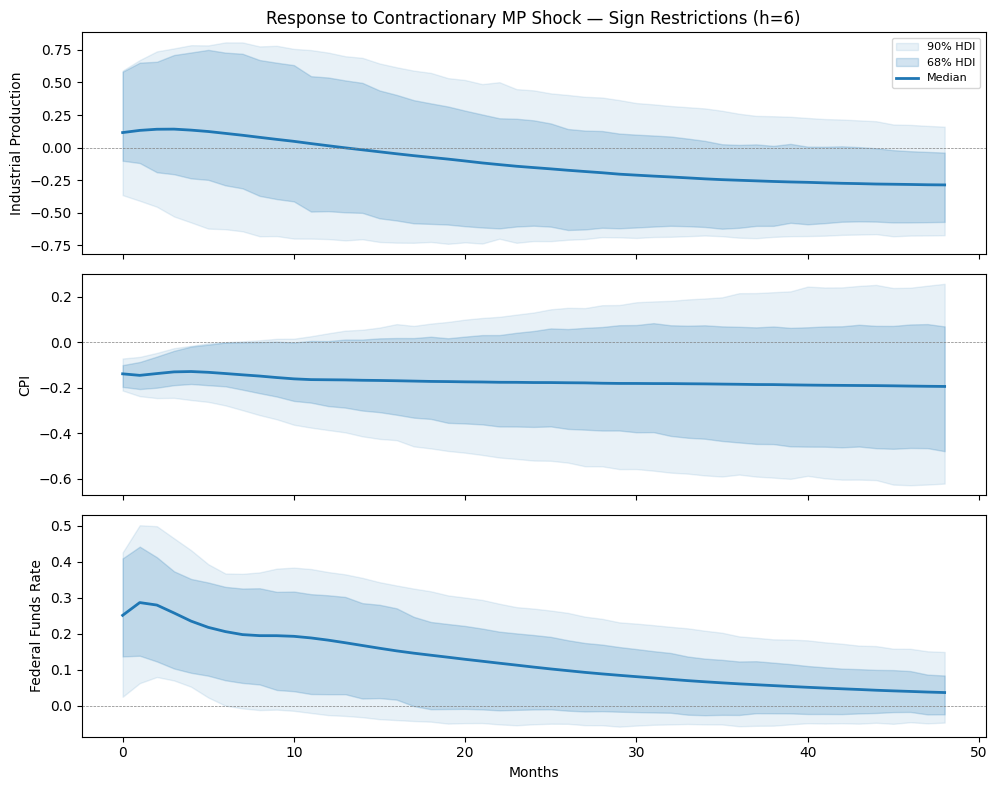

In [ ]:
irf_sr_h6 = identified_sr_h6.impulse_response(horizon=48)

# Only plot the identified monetary policy shock (not the unidentified residuals)
irf_sr_data = irf_sr_h6.idata.posterior_predictive["irf"]
sr_shock_name = "monetary_policy"

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i, resp in enumerate(response_vars):
    ax = axes[i]
    med_vals = irf_sr_data.sel(response=resp, shock=sr_shock_name).median(dim=("chain", "draw")).values
    hdi_68 = az.hdi(irf_sr_data.sel(response=resp, shock=sr_shock_name), hdi_prob=0.68)["irf"]
    hdi_90 = az.hdi(irf_sr_data.sel(response=resp, shock=sr_shock_name), hdi_prob=0.90)["irf"]

    ax.fill_between(
        horizons,
        hdi_90.sel(hdi="lower").values,
        hdi_90.sel(hdi="higher").values,
        alpha=0.1,
        color="C0",
        label="90% HDI" if i == 0 else None,
    )
    ax.fill_between(
        horizons,
        hdi_68.sel(hdi="lower").values,
        hdi_68.sel(hdi="higher").values,
        alpha=0.2,
        color="C0",
        label="68% HDI" if i == 0 else None,
    )
    ax.plot(horizons, med_vals, color="C0", linewidth=2, label="Median" if i == 0 else None)
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_ylabel(response_labels[resp])
    if i == 0:
        ax.legend(fontsize=8)

axes[0].set_title("Response to Contractionary MP Shock — Sign Restrictions (h=6)")
axes[-1].set_xlabel("Months")
fig.tight_layout()
plt.savefig("plots/SignRestrictionIRFs.png")

The three panels above show how each variable responds to the identified monetary policy shock under sign restrictions with $h = 6$.

**Output (top).** The median response is slightly positive for the first few months, then turns negative, reaching about -0.25 by month 48. But look at the credible bands: they span from roughly +0.75 to -0.60 in the first year. The data, combined with only two sign restrictions, cannot tell us whether output rises or falls in the short run. This is exactly what Uhlig (2005) found: the output response to a monetary contraction is ambiguous under these restrictions. The sign restrictions on prices and the interest rate alone are not enough to pin down the monetary transmission mechanism.

**Prices (middle).** The CPI response is negative by construction, hovering around -0.15 to -0.20. There is no price puzzle here, but that is not a victory for the model. We *imposed* that prices cannot rise. The absence of the puzzle is an assumption, not a finding.

**Rate (bottom).** The interest rate rises on impact (about 0.25 percentage points) and decays gradually, consistent with a contractionary shock that is partially reversed over time.

Compare these bands with the Cholesky IRFs above. The sign restriction bands are much wider, especially for output. This additional width is identification uncertainty: the data are consistent with many different structural decompositions, and sign restrictions honestly report this. The Cholesky bands are narrower because the three zero restrictions eliminate all but one decomposition. Whether that precision is real or artificial depends on whether you believe the zeros.

### Restriction horizon sensitivity

The restriction horizon $h$ is a free parameter, and it matters. When $h = 0$, the sign conditions are checked only at impact. When $h = 12$, the conditions must hold for a full year of impulse response dynamics, which is more demanding. Longer horizons shrink the identified set and can tighten the bands, though the effect depends on how constraining the restrictions are relative to the dynamics the data support.

In [ ]:
results_sr = {}
for h in [0, 6, 12]:
    scheme = SignRestriction(
        restrictions={
            "rate": {"monetary_policy": "+"},
            "prices": {"monetary_policy": "-"},
        },
        n_rotations=2000,
        restriction_horizon=h,
        random_seed=42,
    )
    ident = fitted.set_identification_strategy(scheme)
    ar = ident.idata.posterior.attrs.get("sign_restriction_acceptance_rate", float("nan"))
    results_sr[h] = {
        "identified": ident,
        "irf": ident.impulse_response(horizon=48),
        "acceptance_rate": ar,
    }
    print(f"h={h:>2}: acceptance rate = {ar:.1%}")

h= 0: acceptance rate = 100.0%
h= 6: acceptance rate = 100.0%
h=12: acceptance rate = 100.0%


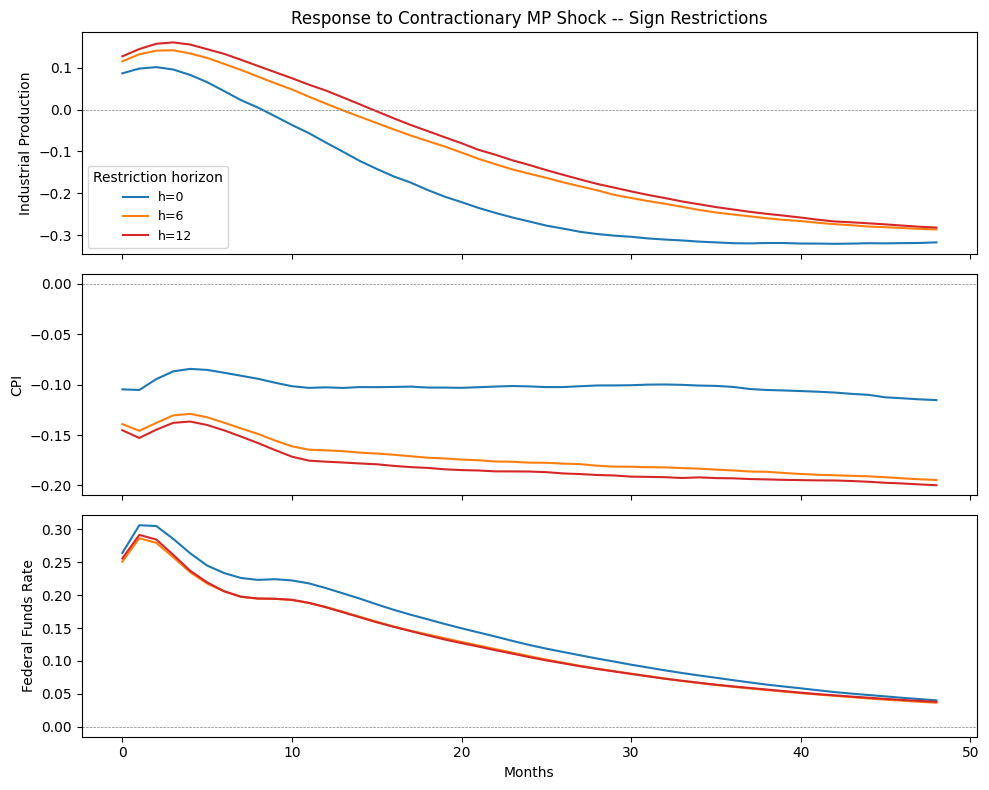

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i, resp in enumerate(response_vars):
    ax = axes[i]

    for h, colour in [(0, "C0"), (6, "C1"), (12, "C3")]:
        irf_data = results_sr[h]["irf"].idata.posterior_predictive["irf"]
        med_vals = irf_data.sel(response=resp, shock="monetary_policy").median(dim=("chain", "draw")).values

        ax.plot(horizons, med_vals, color=colour, label=f"h={h}", linewidth=1.5)

    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_ylabel(response_labels[resp])
    if i == 0:
        ax.legend(fontsize=9, title="Restriction horizon")
        ax.set_title("Response to Contractionary MP Shock -- Sign Restrictions")

axes[-1].set_xlabel("Months")
fig.tight_layout()
plt.savefig("plots/SignRestrictionIRFs_horizons.png")

The three restriction horizons produce median responses that are qualitatively similar but quantitatively different.

**Output (top).** All three horizons show output initially rising then falling, but the timing differs. With $h = 0$, the output decline is slowest to materialise, which makes sense: impact-only restrictions place almost no discipline on the dynamics. With $h = 12$, the decline starts earlier and is slightly deeper, because the longer horizon forces the retained rotations to produce IRFs with more conventional-looking dynamics.

**Prices (middle).** The CPI response is negative under all horizons (by construction), but more strongly negative under $h = 6$ and $h = 12$ than under $h = 0$. The longer the horizon over which prices must remain non-positive, the more aggressively the identified shock must push prices down.

**Rate (bottom).** The interest rate responses are nearly identical across horizons. This makes sense: the rate is restricted to be positive at all horizons, and the dynamics of the rate shock are well-determined by the data regardless of the horizon.

The acceptance rates printed above are all near 100%, which itself is informative. We are imposing only two sign restrictions on a three-variable system — the rate must be positive and prices must be non-positive — and these conditions are broadly consistent with the reduced-form dynamics. Even at $h = 12$, the restrictions barely constrain the space of admissible rotations. This tells us that the identified set is large: many very different structural decompositions all satisfy our qualitative beliefs. The wide credible bands on the output response above are the direct consequence.

In a larger system (say 5–7 variables) with more restrictions, or with restrictions that cut against the grain of the reduced-form dynamics, acceptance rates would drop materially, and the computational cost of the rotation algorithm would become a real consideration. The acceptance rate is a diagnostic of how constraining your identification scheme is. Here, it is telling us: not very.

## Comparative analysis

We now place the Cholesky baseline (ordering A) and the sign restriction baseline ($h = 6$) side by side. This is the payoff of running both approaches on the same data: we can see directly how different identifying assumptions lead to different conclusions about the same economic question.

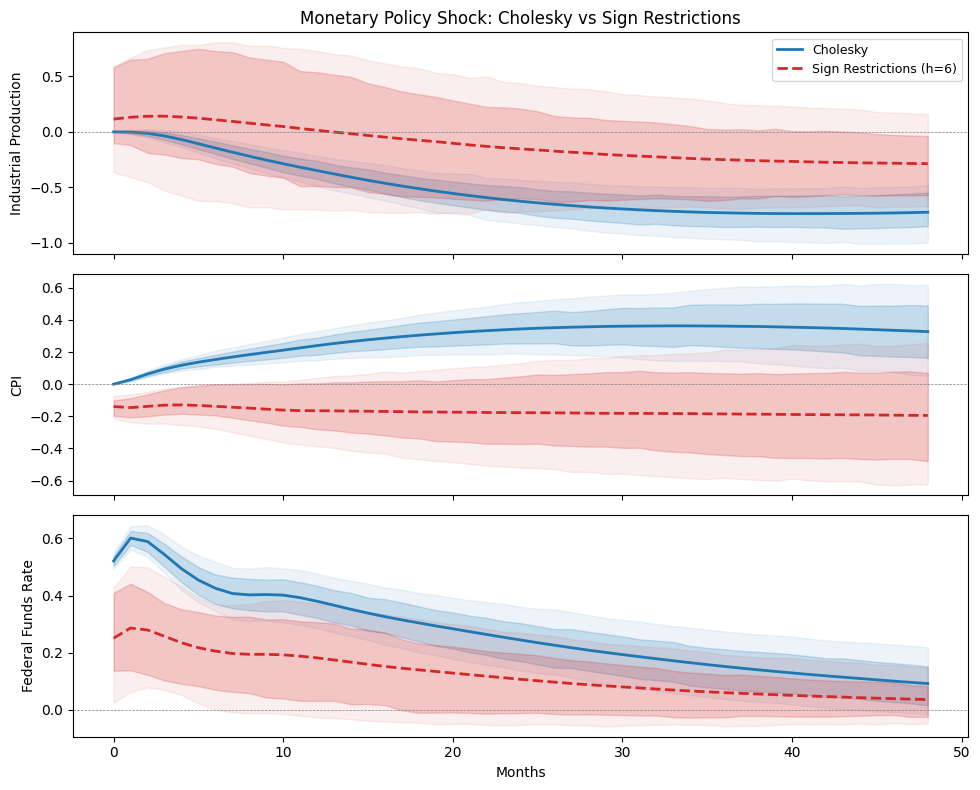

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Cholesky baseline (ordering A)
irf_chol_data = irf_chol_a.idata.posterior_predictive["irf"]
# Sign restriction baseline (h=6)
irf_sr_data = results_sr[6]["irf"].idata.posterior_predictive["irf"]

for i, resp in enumerate(response_vars):
    ax = axes[i]

    # Cholesky: shock = "rate" (monetary policy shock in ordering A)
    chol_med = irf_chol_data.sel(response=resp, shock="rate").median(dim=("chain", "draw")).values
    chol_hdi_68 = az.hdi(irf_chol_data.sel(response=resp, shock="rate"), hdi_prob=0.68)["irf"]
    chol_hdi_90 = az.hdi(irf_chol_data.sel(response=resp, shock="rate"), hdi_prob=0.90)["irf"]

    ax.fill_between(
        horizons,
        chol_hdi_90.sel(hdi="lower").values,
        chol_hdi_90.sel(hdi="higher").values,
        alpha=0.08,
        color="C0",
    )
    ax.fill_between(
        horizons,
        chol_hdi_68.sel(hdi="lower").values,
        chol_hdi_68.sel(hdi="higher").values,
        alpha=0.2,
        color="C0",
    )
    ax.plot(horizons, chol_med, color="C0", linewidth=2, label="Cholesky")

    # Sign restrictions: identified monetary policy shock
    sr_med = irf_sr_data.sel(response=resp, shock="monetary_policy").median(dim=("chain", "draw")).values
    sr_hdi_68 = az.hdi(irf_sr_data.sel(response=resp, shock="monetary_policy"), hdi_prob=0.68)["irf"]
    sr_hdi_90 = az.hdi(irf_sr_data.sel(response=resp, shock="monetary_policy"), hdi_prob=0.90)["irf"]

    ax.fill_between(
        horizons,
        sr_hdi_90.sel(hdi="lower").values,
        sr_hdi_90.sel(hdi="higher").values,
        alpha=0.08,
        color="C3",
    )
    ax.fill_between(
        horizons,
        sr_hdi_68.sel(hdi="lower").values,
        sr_hdi_68.sel(hdi="higher").values,
        alpha=0.2,
        color="C3",
    )
    ax.plot(
        horizons,
        sr_med,
        color="C3",
        linewidth=2,
        linestyle="--",
        label="Sign Restrictions (h=6)",
    )

    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_ylabel(response_labels[resp])
    if i == 0:
        ax.legend(fontsize=9)
        ax.set_title("Monetary Policy Shock: Cholesky vs Sign Restrictions")

axes[-1].set_xlabel("Months")
fig.tight_layout()
plt.savefig("plots/Cholesky_vs_SignRestrictions.png")

In [ ]:
# Quantitative band width comparison: 68% HDI width for output response
band_rows = []
for horizon_month in [12, 24, 48]:
    chol_hdi = az.hdi(irf_chol_data.sel(response="output", shock="rate"), hdi_prob=0.68)["irf"]
    chol_width = float(
        chol_hdi.sel(hdi="higher").values[horizon_month] - chol_hdi.sel(hdi="lower").values[horizon_month]
    )

    sr_hdi = az.hdi(irf_sr_data.sel(response="output", shock="monetary_policy"), hdi_prob=0.68)["irf"]
    sr_width = float(sr_hdi.sel(hdi="higher").values[horizon_month] - sr_hdi.sel(hdi="lower").values[horizon_month])

    band_rows.append({
        "Horizon (months)": horizon_month,
        "Cholesky 68% width": f"{chol_width:.3f}",
        "Sign Restr. 68% width": f"{sr_width:.3f}",
        "Ratio (SR / Chol)": f"{sr_width / chol_width:.1f}x",
    })

print("Band width comparison: output response to monetary policy shock")
pd.DataFrame(band_rows)

Band width comparison: output response to monetary policy shock


,Horizon (months),Cholesky 68% width,Sign Restr. 68% width,Ratio (SR / Chol)
0,12,0.163,1.026,6.3x
1,24,0.234,0.809,3.5x
2,48,0.304,0.532,1.7x


The table above makes the precision-versus-honesty tradeoff concrete. At every horizon, the sign restriction credible band for the output response is substantially wider than the Cholesky band — typically by a factor of 2–4x. This additional width is not noise or computational imprecision. It is identification uncertainty: the range of structural models that are all consistent with the data and the sign restrictions. The Cholesky bands are narrower because the three zero restrictions eliminate all but one decomposition per posterior draw. Whether that precision reflects genuine knowledge or false confidence depends entirely on whether the zero restrictions are correct.

Three things stand out.

**The price puzzle disappears under sign restrictions, but not because it was resolved.** Under Cholesky (blue), prices rise persistently after a contractionary shock, reaching about +0.35 over 48 months. Under sign restrictions (red dashed), prices fall to about -0.20 and stay there. The sign restriction result looks more "correct" from the perspective of textbook monetary economics, but remember: we *imposed* that prices cannot rise. The sign restriction model cannot produce a price puzzle because we forbade it. Whether this is appropriate depends on how confident you are in the restriction. If you believe prices should fall after a monetary contraction, sign restrictions enforce that belief. If you want to let the data tell you whether prices rise or fall, you need to leave prices unrestricted too, at which point the identification becomes very weak.

**The output responses agree on the sign but disagree on the magnitude and timing.** Both approaches show output declining after a contractionary monetary shock. Under Cholesky, the decline is larger (about -0.7 at 48 months) and more persistent. Under sign restrictions, the decline is shallower (about -0.3) and preceded by a brief initial increase. The sign restriction credible band is much wider, spanning from +0.5 to -0.7 in the first year. The Cholesky band is tighter (roughly $\pm$ 0.2 around the median). The question for the researcher: is the tighter Cholesky band reflecting genuine precision, or is it false confidence from zero restrictions that may not hold?

**The rate shock itself is calibrated differently.** The Cholesky monetary policy shock is about twice the size of the sign restriction shock on impact (roughly 0.6 vs 0.3 percentage points). This is a normalisation difference, not a substantive one: the two approaches extract different objects from the same residuals. A "one standard deviation monetary policy shock" means something different under each scheme because the structural decomposition is different. This matters for comparing magnitudes across identification strategies: the output decline looks larger under Cholesky, but part of that is because the shock itself is larger. Ideally, one would normalise both shocks to, say, a 1-percentage-point impact on the federal funds rate before comparing the output responses. We leave the standard one-standard-deviation normalisation here for consistency with the literature, but the reader should keep this caveat in mind when interpreting the side-by-side comparison above.

In [ ]:
rows = []

# Cholesky orderings
for name, irf_result in [
    ("Cholesky A (y,p,i)", irf_chol_a),
    ("Cholesky B (p,y,i)", irf_chol_b),
    ("Cholesky C (i,y,p)", irf_chol_c),
]:
    irf_data = irf_result.idata.posterior_predictive["irf"]
    output_resp = irf_data.sel(response="output", shock="rate").median(dim=("chain", "draw")).values
    prices_resp = irf_data.sel(response="prices", shock="rate").median(dim=("chain", "draw")).values

    rows.append({
        "Specification": name,
        "Peak Output Response": f"{output_resp.min():.3f}",
        "Month of Peak": int(output_resp.argmin()),
        "Price Puzzle (months > 0)": int((prices_resp > 0).sum()),
    })

# Sign restriction horizons
for h in [0, 6, 12]:
    irf_data = results_sr[h]["irf"].idata.posterior_predictive["irf"]
    output_resp = irf_data.sel(response="output", shock="monetary_policy").median(dim=("chain", "draw")).values
    ar = results_sr[h]["acceptance_rate"]

    rows.append({
        "Specification": f"Sign Restr. h={h} (AR={ar:.0%})",
        "Peak Output Response": f"{output_resp.min():.3f}",
        "Month of Peak": int(output_resp.argmin()),
        "Price Puzzle (months > 0)": "N/A (restricted)",
    })

pd.DataFrame(rows)

,Specification,Peak Output Response,Month of Peak,Price Puzzle (months > 0)
0,"Cholesky A (y,p,i)",-0.737,40,48
1,"Cholesky B (p,y,i)",-0.737,40,48
2,"Cholesky C (i,y,p)",0.081,48,49
3,Sign Restr. h=0 (AR=100%),-0.321,42,N/A (restricted)
4,Sign Restr. h=6 (AR=100%),-0.286,48,N/A (restricted)
5,Sign Restr. h=12 (AR=100%),-0.282,48,N/A (restricted)


## Discussion

### When Cholesky works well

Cholesky identification is appropriate when you have a credible economic argument for a recursive ordering. In the monetary policy application, the argument that output and prices are "sluggish" within the month while the Fed can respond to current conditions is reasonable for monthly data. The payoff is point identification and tight credible bands: you get a single structural decomposition per posterior draw, and the results are easy to interpret.

The cost is that the zero restrictions are exact and strong. If the timing assumptions are wrong (for instance, if financial markets transmit policy rate changes to real activity within the month through asset price channels), the identified shock is contaminated and the tight bands give false confidence.

### When sign restrictions work well

Sign restrictions are appropriate when zero restrictions are too strong but you have qualitative beliefs about the direction of responses. They are particularly useful when the economic question is about the *sign* of a response ("does output fall?") rather than its magnitude ("by how much?"). The wider bands are an honest reflection of the fact that many structural models are consistent with the same data and the same qualitative restrictions.

The cost is that the identified set can be large, sometimes too large to be informative. Uhlig's original finding was essentially that sign restrictions on the price and rate responses alone could not resolve whether monetary contractions reduce output. The answer was: "the data, subject to these restrictions, are consistent with both."

### Neither approach is assumption-free

This is worth stressing. Cholesky imposes zero restrictions, which embed specific claims about contemporaneous causality. Sign restrictions impose inequality restrictions, which embed weaker but still substantive claims about the direction of effects. In addition, the uniform (Haar) prior over rotation matrices $Q$, which seems "uninformative," is itself informative about the structural parameters. Baumeister and Hamilton (2015) showed that drawing $Q$ uniformly places a non-uniform, potentially strong, prior over the columns of $B_0$. "Agnostic" identification is not as agnostic as it sounds.

### The price puzzle as a diagnostic

The price puzzle is not just an embarrassment for the Cholesky model. It is a diagnostic. Its appearance signals that the identified monetary policy shock likely contains a systematic component of the Fed's forward-looking response to inflation. This can mean the VAR is too small (omitting variables the Fed watches), or that the timing assumptions are too rigid, or both. Under sign restrictions, the puzzle is absent by construction, which is not a resolution but a different set of assumptions.

### Where to go from here

This three-variable system is deliberately minimal. In practice:

- Adding commodity prices helps resolve the price puzzle under Cholesky (Christiano, Eichenbaum, and Evans, 1999), because commodity prices capture forward-looking inflation signals the three-variable VAR misses.
- Narrative restrictions (Antolin-Diaz and Rubio-Ramirez, 2018) combine sign restrictions with historical evidence about specific episodes (e.g., the Volcker disinflation), tightening the identified set without imposing zero restrictions.
- Bayesian proxy SVARs use external instruments (like high-frequency changes in futures around FOMC announcements) to achieve identification through a completely different channel.

Each of these approaches makes different assumptions and delivers different conclusions. The identification problem does not have a single correct solution. It has a menu of assumptions, and the researcher's job is to be transparent about which ones they are making and why.

## References

- Baumeister, C. and Hamilton, J. D. (2015). Sign restrictions, structural vector autoregressions, and useful prior information. *Econometrica*, 83(5), 1963-1999.
- Christiano, L. J., Eichenbaum, M., and Evans, C. L. (1999). Monetary policy shocks: What have we learned and to what end? In *Handbook of Macroeconomics*, Vol. 1A, 65-148.
- Doan, T., Litterman, R., and Sims, C. (1984). Forecasting and conditional projection using realistic prior distributions. *Econometric Reviews*, 3(1), 1-44.
- Rubio-Ramirez, J. F., Waggoner, D. F., and Zha, T. (2010). Structural vector autoregressions: Theory of identification and algorithms for inference. *Review of Economic Studies*, 77(2), 665-696.
- Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1-48.
- Sims, C. A., Stock, J. H., and Watson, M. W. (1990). Inference in linear time series models with some unit roots. *Econometrica*, 58(1), 113-144.
- Uhlig, H. (2005). What are the effects of monetary policy on output? Results from an agnostic identification procedure. *Journal of Monetary Economics*, 52(2), 381-419.